In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [30]:
df = pd.read_csv("../result.csv")

In [31]:
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")  # 可选风格: darkgrid/whitegrid/dark/white/ticks[3,4](@ref)
sns.set_palette("husl")          # 调色板：deep/muted/bright/pastel等[3](@ref)

In [32]:
df[['test_type', 'data_size']] = df['name'].str.split('/', expand=True)
df[['operation', 'container']] = df['test_type'].str.split('_', n=2, expand=True)[[1,2]]

# 转换时间单位（纳秒转微秒）
df['real_time_us'] = df['real_time'] / 1000
df['cpu_time_us'] = df['cpu_time'] / 1000

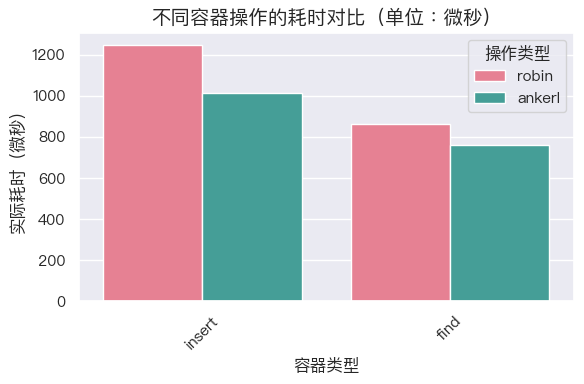

In [34]:
plt.figure(figsize=(6, 4))
plt.rcParams['font.sans-serif'] = ['PingFang HK']  # macOS 推荐
sns.barplot(
    data=df,
    x='container',
    y='real_time_us',
    hue='operation',
    errorbar=None,
    palette='husl',
    estimator='mean'  # 默认计算均值
)
plt.title('不同容器操作的耗时对比（单位：微秒）', fontsize=14)
plt.xlabel('容器类型')
plt.ylabel('实际耗时（微秒）')
plt.legend(title='操作类型')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()